<a href="https://colab.research.google.com/github/varrahan/gemini-coding-agent/blob/main/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [24]:
# Import all the necessary libraries here

import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import numpy as np

Mount Google Drive and unzip the dataset.

In [19]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')
print("Actual column names in CSV:", train_label.columns.tolist())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/FH_detection_data.zip
replace /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  


----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ We need to check for class imbalance because a skewed dataset can cause the model to develop a bias toward the majority class. This would result in a high accuracy while completely failing at its actual goal of the model


Sample Images from Training Set:


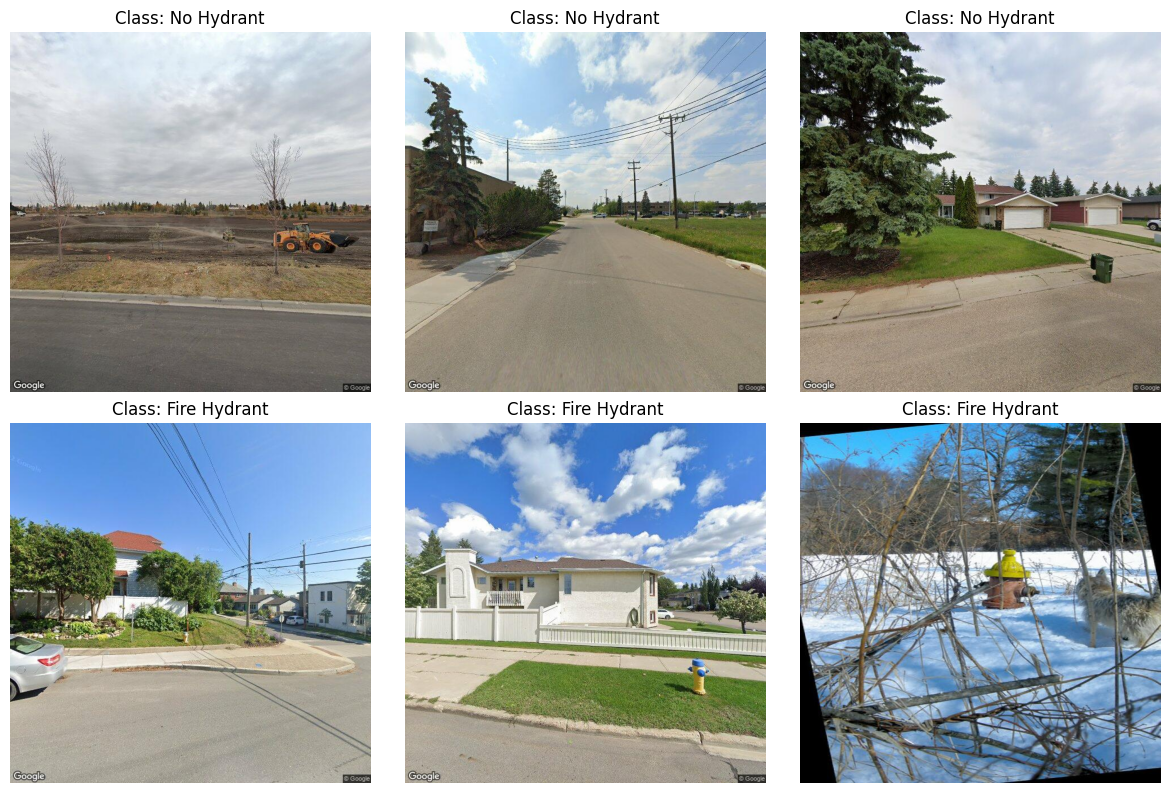

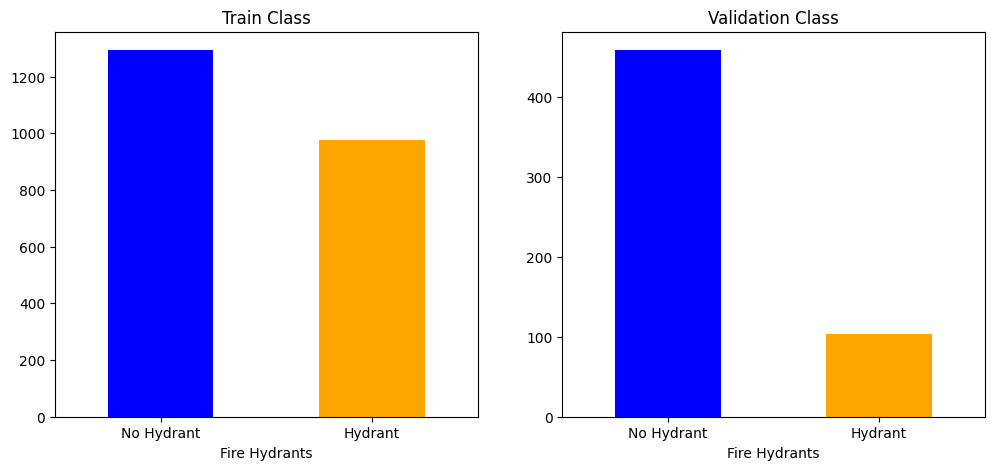

In [16]:
# Load dataset and clean up column nmaes
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')
train_label.columns = [col.strip() for col in train_label.columns]
valid_label.columns = [col.strip() for col in valid_label.columns]

# Display three sample images per class
def show_samples(df, img_dir):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for label, ax_row in zip([0, 1], axes):
        samples = df[df['Fire Hydrants'] == label].sample(3)
        for ax, (_, row) in zip(ax_row, samples.iterrows()):
            img_path = os.path.join(img_dir, row['filename'])
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"Class: {'Fire Hydrant' if label == 1 else 'No Hydrant'}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Sample Images from Training Set:")
show_samples(train_label, '/content/train')

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
train_label['Fire Hydrants'].value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'orange'])
axes[0].set_title('Train Class')
axes[0].set_xticklabels(['No Hydrant', 'Hydrant'], rotation=0)

valid_label['Fire Hydrants'].value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'orange'])
axes[1].set_title('Validation Class')
axes[1].set_xticklabels(['No Hydrant', 'Hydrant'], rotation=0)
plt.show()

---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ It is not necessary for binary classfication, as binary representation 1 and 0 already serve the purpose. There's no need to create a new column when we have a binary representation.

In [30]:
# Dataset class to support batch loaders for training and validation
class FireHydrantDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.dataframe.iloc[idx]['filename'])
        image = Image.open(img_name).convert('RGB')
        label = float(self.dataframe.iloc[idx]['Fire Hydrants'])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor([label], dtype=torch.float32)

# Transofrm
baseline_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = FireHydrantDataset(train_label, '/content/train', transform=baseline_transform)
valid_dataset = FireHydrantDataset(valid_label, '/content/valid', transform=baseline_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ Add data augmentation to expand the dataset by applying arbitrary transformations, reducing the risk of overfitting. Add a dropout layer to prevent overfitting by forcing the NN to learn more impactful features. Add weighted loss to penalize missing the minority class over the majority class.

In [31]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
baseline_model = CNN().to(device)

---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ I think the F1 score is most suitable, as the dataset has an imbalance of classes, which can lead to overfitting as the model could just end up continuously picking the majority class. By using the F1 score, a balanced metric independent of accuracy is used.

Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ A confusion matrix is a grid that shows where the model went wrong. The top left shows the number of times we correctly guessed that there is no hydrant, the bottom right represents when we correctly guessed that there was a hydrant. The other 2 squares are false alarms, and it is when we essentially pick the wrong choice. It relates to the F1 score because the F1 score is calculated based on the numbers in the matrix

Epoch 1/10, Loss: 0.6642
Epoch 2/10, Loss: 0.4842
Epoch 3/10, Loss: 0.4447
Epoch 4/10, Loss: 0.3537
Epoch 5/10, Loss: 0.2813
Epoch 6/10, Loss: 0.1959
Epoch 7/10, Loss: 0.1280
Epoch 8/10, Loss: 0.0901
Epoch 9/10, Loss: 0.0525
Epoch 10/10, Loss: 0.0303

Baseline Validation Metrics:
Precision: 0.4167
Recall: 0.6250
F1-Score: 0.5000


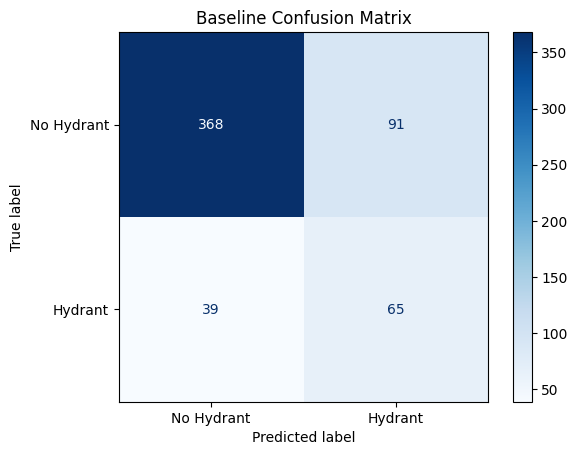

In [32]:
criterion = nn.BCELoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

# Training Loop
epochs = 10
for epoch in range(epochs):
    baseline_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluation Loop
baseline_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = baseline_model(images)
        preds = (outputs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print(f"\nBaseline Validation Metrics:\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1-Score: {f1:.4f}")
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Hydrant', 'Hydrant'])
disp.plot(cmap='Blues')
plt.title("Baseline Confusion Matrix")
plt.show()

---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ I would deploy the model that has data augmentation and weighted loss, as the baseline model overfits easily to the dominant background class. The weighted loss make it so that the NN maps features belonging to the fire hydrant, and the augmentation ensures the model behaves reliably in different environments.

In [37]:
# Data Augmentation & Dropout Model
aug_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_loader_aug = DataLoader(FireHydrantDataset(train_label, '/content/train', transform=aug_transform), batch_size=32, shuffle=True)

class CNNWithAura(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 32 * 32, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

aura_model = CNNWithAura().to(device)
pos_weight = torch.tensor([(len(train_label) - train_label['Fire Hydrants'].sum()) / train_label['Fire Hydrants'].sum()]).to(device)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_imp = optim.Adam(aura_model.parameters(), lr=0.001)

# Train
print("Training...")
for epoch in range(10):
    aura_model.train()
    for images, labels in train_loader_aug:
        optimizer_imp.zero_grad()
        loss = criterion_weighted(aura_model(images.to(device)), labels.to(device))
        loss.backward()
        optimizer_imp.step()

# Evaluate
aura_model.eval()
all_preds_imp, all_labels_imp = [], []

with torch.no_grad():
    for images, labels in valid_loader:
        preds = (torch.sigmoid(aura_model(images.to(device))) > 0.5).float()
        all_preds_imp.extend(preds.cpu().numpy())
        all_labels_imp.extend(labels.numpy())

print(f"\Metrics:")
print(f"Precision: {precision_score(all_labels_imp, all_preds_imp):.4f}")
print(f"Recall: {recall_score(all_labels_imp, all_preds_imp):.4f}")
print(f"F1-Score: {f1_score(all_labels_imp, all_preds_imp):.4f}")

<>:54: SyntaxWarning: invalid escape sequence '\M'
<>:54: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_142/2249191353.py:54: SyntaxWarning: invalid escape sequence '\M'
  print(f"\Metrics:")


Training Improved Model...
\Metrics:
Precision: 0.3333
Recall: 0.7115
F1-Score: 0.4540


---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ I used a water buoy in the ocean in image, and the model predicted it as a hydrant, with a propability of 0.88.

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ I believe the model performed the way the way it did on the first image because it prioritized the general shape of of the hydrant, like the nozzles and bolts on it.

In the second and fourth image, the model identifed the hydrant that was spraying water. I believe that the model can also identify the pattern of spraying water from a specific point of the fire hydrant.

The third image showed that the model was  tricked by the red buoy. This shows the CNN has learned to heavily associate the cylindrical and domed shapes with the hydrants.

In the fifth image, the model predicted the hydrant with low confidence of 0.69. This is most likely because of the strange shape of the hydrant itself. It is unique with slightly similar features to that of a traditional hydrant.

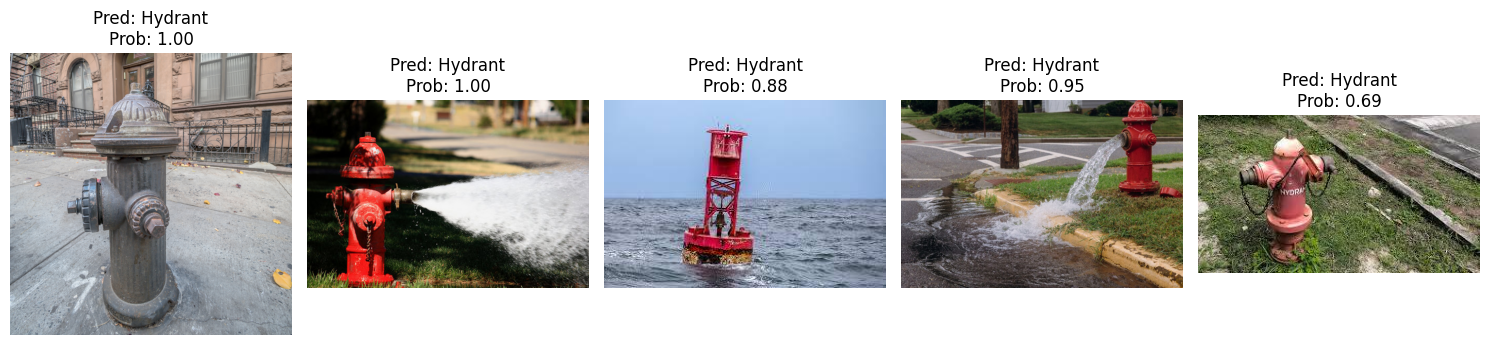

In [39]:
test_images = ['test1.png', 'test2.jpg', 'test3.jpg', 'test4.jpg', 'test5.jpg']

aura_model.eval()
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

with torch.no_grad():
    for ax, img_name in zip(axes, test_images):
        if os.path.exists(img_name):
            image = Image.open(img_name).convert('RGB')
            input_tensor = baseline_transform(image).unsqueeze(0).to(device)

            output = aura_model(input_tensor)
            prob = torch.sigmoid(output).item()
            pred = "Hydrant" if prob > 0.5 else "No Hydrant"

            ax.imshow(image)
            ax.set_title(f"Pred: {pred}\nProb: {prob:.2f}")
            ax.axis('off')
        else:
            print(f"File {img_name} not found.")
plt.tight_layout()
plt.show()

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ To improve the model, I would move from simple image classification to an object detection model like YOLO. Since hydrants are often small objects within a larger scene, object detection would allow the model to highlight the hydrant with bounding boxes, disregarding the background. Expanding the dataset with images of hydrants in different weather and different colors would vastly improve robustness.


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Yeah, I used Gemini to assist with making the boilerplate PyTorch training loops and CNN. I prompted it to help structure my PyTorch DataLoader logic and map out the parameters for the Convolutional layers. I validated the response by running the code blocks to ensure tensor dimensions matched and verifying the output metrics against the expectations


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

